# Example of running and analysing the energy system model of the NL

In [1]:
import calliope
import pandas as pd

calliope.set_log_verbosity("INFO", include_solver_output=True)

# 1. Reference case
## 1.1. Create and solve the model

In [2]:
model = calliope.read_yaml('C:\\Users\\amran\\Downloads\\SEN1531_Integrated_Energy_sys\\SEN1531_Integrated_Energy_sys\\calliope_integrated\\model_starter_toolkit\\calliope_model\\model\\model.yaml')

[2026-03-14 14:13:04] INFO     Math init | loading pre-defined math.
[2026-03-14 14:13:04] INFO     Math init | loading math files {'operate', 'storage_inter_cluster', 'base', 'milp', 'spores'}.
[2026-03-14 14:13:04] INFO     Model: preprocessing data
[2026-03-14 14:13:05] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 14:13:05] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:05] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:05] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:05] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:05] INFO     Model: initialisation complete


In [3]:
model.inputs.sink_use_equals.to_series().dropna()

timesteps            nodes  techs       
2025-01-01 00:00:00  NLD    demand_power    12567.367
2025-01-01 01:00:00  NLD    demand_power    11937.461
2025-01-01 02:00:00  NLD    demand_power    11899.610
2025-01-01 03:00:00  NLD    demand_power    11692.961
2025-01-01 04:00:00  NLD    demand_power    11338.905
                                              ...    
2025-01-31 19:00:00  NLD    demand_power    16645.245
2025-01-31 20:00:00  NLD    demand_power    16468.767
2025-01-31 21:00:00  NLD    demand_power    16055.844
2025-01-31 22:00:00  NLD    demand_power    14589.335
2025-01-31 23:00:00  NLD    demand_power    13585.091
Name: sink_use_equals, Length: 744, dtype: float64

In [4]:
# print(balance_price['system_balance'].dtype)
# print(balance_price['timesteps'].dtype)

# mask = pd.to_datetime(balance_price['timesteps']).isin(days_of_interest)
# print(mask.sum())  # how many matched rows?


In [5]:
import os, calliope
os.chdir(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
model = calliope.read_yaml("model/model.yaml")
model.build()
model.solve()


print(model.results.attrs.get("termination_condition"))  # should be optimal/feasible
model.to_netcdf("results/default_results.nc")


[2026-03-14 14:13:05] INFO     Math init | loading pre-defined math.
[2026-03-14 14:13:05] INFO     Math init | loading math files {'operate', 'storage_inter_cluster', 'base', 'milp', 'spores'}.
[2026-03-14 14:13:05] INFO     Model: preprocessing data
[2026-03-14 14:13:05] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 14:13:06] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:06] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:06] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:06] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:06] INFO     Model: initialisation complete
[2026-03-14 14:13:06] INFO     Model: backend build starting
[2026-03-14

## 1.2. Do a first sense-check of the results

In [6]:
# Shadow price for the power system balance constraint
balance_price = model.backend.shadow_prices.get("system_balance").to_series().reset_index()
balance_price.head()

,nodes,carriers,timesteps,system_balance
0,NLD,hydrogen,2025-01-01 00:00:00,-0.0
1,NLD,hydrogen,2025-01-01 01:00:00,-0.0
2,NLD,hydrogen,2025-01-01 02:00:00,-0.0
3,NLD,hydrogen,2025-01-01 03:00:00,-0.0
4,NLD,hydrogen,2025-01-01 04:00:00,-0.0


<Axes: >

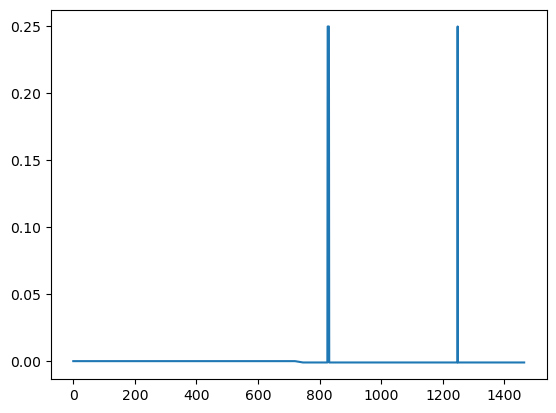

In [7]:
# Create a Date Range to select a few days in November to inspect visually
days_of_interest = pd.date_range('2025-01-01','2025-01-31',freq='h') 
# Plot the days of interest
balance_price['system_balance'].loc[balance_price['timesteps'].isin(days_of_interest)].plot()

Because the model is very simple, the price always matches the price of the CCGT unless renewables are capable of meeting demand by themselves. We can check that the value shown in the shadow price is indeed the marginal cost of the CCGT by performing a few steps. The marginal cost is, in fact, the ratio between the variable co

In [8]:
variable_costs = model.results.cost_operation_variable.to_series().dropna()
variable_costs.head()

nodes  techs            costs     timesteps          
NLD    battery_storage  monetary  2025-01-01 00:00:00    0.0
                                  2025-01-01 01:00:00    0.0
                                  2025-01-01 02:00:00    0.0
                                  2025-01-01 03:00:00    0.0
                                  2025-01-01 04:00:00    0.0
Name: cost_operation_variable, dtype: float64

In [9]:
generation = model.results.flow_out.to_series().dropna()
generation.head()

nodes  techs            carriers  timesteps          
NLD    battery_storage  power     2025-01-01 00:00:00    0.0
                                  2025-01-01 01:00:00    0.0
                                  2025-01-01 02:00:00    0.0
                                  2025-01-01 03:00:00    0.0
                                  2025-01-01 04:00:00    0.0
Name: flow_out, dtype: float64

In [10]:
# If we calculate the marginal generation costs per generator type,
# we should see an equivalence between the shadow price in any given
# hour and the marginal cost of the marginal generator in the merit order
marginal_generation_costs = variable_costs/generation
marginal_generation_costs.head()

nodes  techs            costs     timesteps            carriers
NLD    battery_storage  monetary  2025-01-01 00:00:00  power      NaN
                                  2025-01-01 01:00:00  power      NaN
                                  2025-01-01 02:00:00  power      NaN
                                  2025-01-01 03:00:00  power      NaN
                                  2025-01-01 04:00:00  power      NaN
dtype: float64

As expected, the marginal cost of CCGT equals the shadow price. CCGT is the marginal generator in the merit order.

In [11]:
# To check the merit order, we may look at a particular timestep
# and at the list of generators producing in that timestep in ascending cost order.
# The per-timestep selection is easier done before transforming to a Pandas series.
marginal_generation_costs_xr = model.results.cost_operation_variable / model.results.flow_out
# We select a specific hour of the year
my_timestep = '2025-01-02 04:00:00'
# And we select only generators, excluding curtailment and other techs
gen_techs = ['wind_offshore']
# gen_techs = ['solar_pv' ,'wind_offshore', 'wind_onshore', 'ccgt', 'nuclear'] 
# We can now inspect the marginal generation cost in that timestep
marginal_generation_cost_in_timestep = marginal_generation_costs_xr.sel(timesteps=my_timestep, carriers='power', costs='monetary', techs=gen_techs)
marginal_generation_cost_in_timestep.to_series().fillna(0).sort_values()

nodes  techs        
NLD    wind_offshore    0.0
dtype: float64

We see that CCGT, whose marginal generation costs match the shadow price, is the marginal generator. Nuclear isn't used; if it were, the shadow price would be higher and equal to its marginal cost. This can be double-checked by looking at the dispatch plots.

## 1.3. Export the results for further analysis at any later moment

In [12]:
# It is helpful to store the model results as a whole in NetCDF format, which Calliope can import back
# at any later time. 
model.to_netcdf('results/default_results.nc')


In [13]:
# Alternatively, results can be exported as a series of .csv files for inspection and analysis in Excel or
# other software that may benefit from .csv data
#overwrite the .csv files if they already exist
# model.to_csv('results/default_results_csv')

## 1.4. Produce some visualisations

In this example, we provide some pre-made plotting functionalities in the 'plotting_utilities.py' file, which you can import and apply as well as use as an example for making your own custom plots.

In [14]:
# Import some pre-made plotting functionalities as an example. You can use these, make your own, or simply
# create plots with your favourite Python library or non-Python tool, such as Excel
from plotting_utilities import plot_dispatch,plot_load_duration_curve

In [15]:
# Dispatch plots can be generated directly from the saved model results
plot_dispatch(model_path='results/default_results.nc', plot_export_path='results/default_dispatch.html')

[2026-03-14 14:13:14] INFO     Model: preprocessing data (reentry)
[2026-03-14 14:13:14] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 14:13:14] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:14] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:15] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:15] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:15] INFO     Model: initialisation complete


In [16]:
# For generating load duration curves (LDCs), instead, we first need to import back the model results,
# then extract the time-varing variable of interest
model = calliope.read_netcdf('results/default_results.nc')

[2026-03-14 14:13:17] INFO     Model: preprocessing data (reentry)
[2026-03-14 14:13:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-14 14:13:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:18] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:18] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-14 14:13:18] INFO     Model: initialisation complete


In [ ]:
import pandas as pd

print("Termination:", model.results.attrs.get("termination_condition"))

# Energy totals (MWh over model horizon)
demand_served = model.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = model.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = model.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = model.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

# Available wind energy from profile * installed cap
wind_avail = (
    model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    * model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

# Shadow price stats


sp = model.results.shadow_price_system_balance.to_series()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

kpis = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
})

print(kpis)
print("\nSystem balance price stats:")
print(price_stats)



Termination: None
Demand served (MWh)     1.172436e+07
Wind available (MWh)    4.384362e+07
Wind generated (MWh)    4.384362e+07
Curtailment (MWh)       3.214714e+07
Curtailment rate (%)    7.332228e+01
Load shedding (MWh)     2.787908e+04
dtype: float64

System balance price stats:
mean    0.000512
50%     0.000000
95%     0.000000
max     0.250000
Name: shadow_price_system_balance, dtype: float64
